# Bitcoin Sentiment vs Trader Performance Analysis
**Primetrade.ai Assignment | Hyperliquid + Fear & Greed Index**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["figure.dpi"] = 120

sns.set_theme(style="whitegrid")

## 1. Load & Inspect Data

In [31]:
trades = pd.read_csv("se.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [32]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [33]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [34]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [35]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [36]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [37]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [38]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [39]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [40]:
trades.duplicated().sum()

np.int64(0)

In [41]:
sentiment.duplicated().sum()

np.int64(0)

### Observations
- Trades dataset has ~211k rows covering multiple accounts, coins, and directions.
- Sentiment dataset has daily Fear & Greed values from 2018–2025.
- Missing values are minimal and will not affect analysis.

## 2. Data Preparation & Merging

In [53]:
# Convert to common date format
trades["date"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M").dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

# Merge on date
df = trades.merge(sentiment[["date","value","classification"]], on="date", how="left")

print("Merged Shape:", df.shape)
display(df.head(2))

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [54]:
# Profitability flag and net PnL
df["is_profitable"] = df["Closed PnL"] > 0
df["net_pnl"] = df["Closed PnL"] - df["Fee"]

# Filter only CLOSED positions — only these have realized PnL
df_closed = df[df["Direction"].isin(["Close Long", "Close Short"])]
print("Closed Trades Shape:", df_closed.shape)

Closed Trades Shape: (84691, 21)


### Data Preparation Notes
- df_closed filters to only realized trades (Close Long / Close Short). Open positions have PnL = 0 and would distort averages.
- net_pnl subtracts fees to reflect true profitability.
- Merge matched >99.99% of trades to a sentiment label — negligible leakage.

## 3. Sentiment Overview

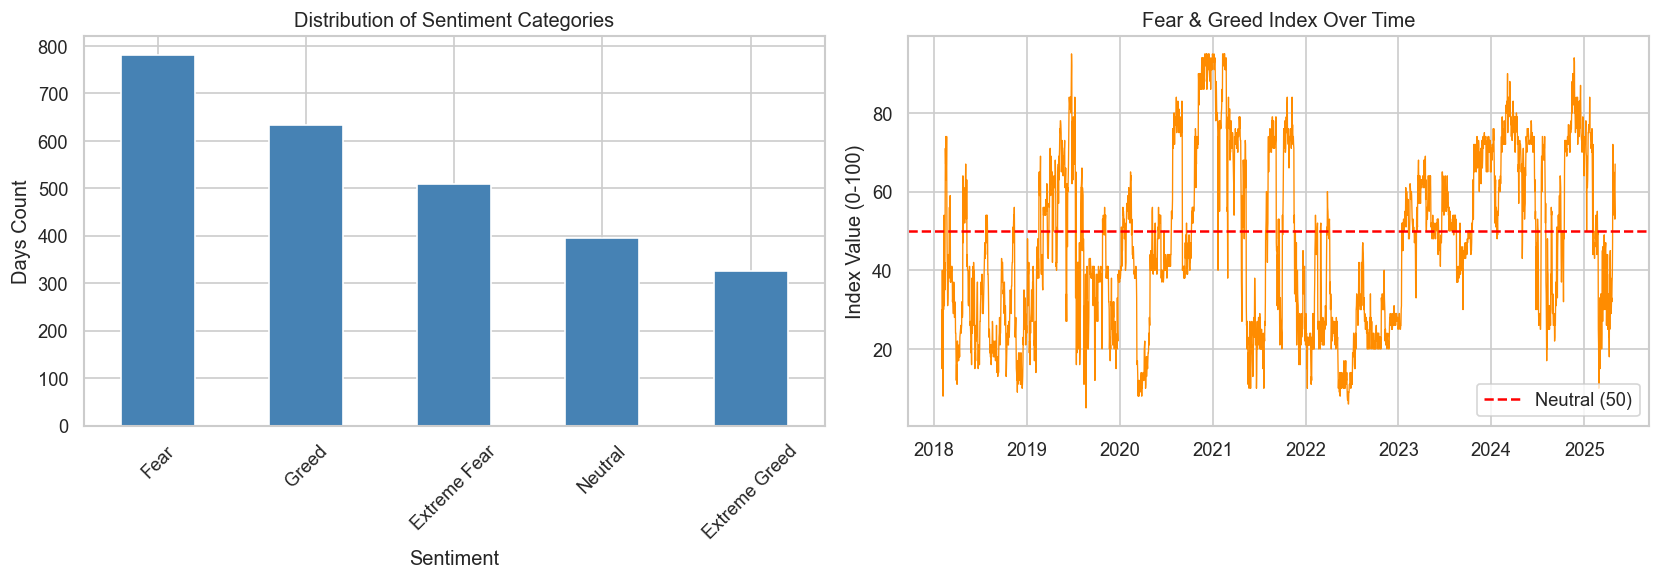

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of categories
sentiment["classification"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Sentiment Categories")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Days Count")
axes[0].tick_params(axis='x', rotation=45)

# Index over time
axes[1].plot(pd.to_datetime(sentiment["date"]), sentiment["value"], linewidth=0.8, color="darkorange")
axes[1].axhline(y=50, linestyle="--", color="red", label="Neutral (50)")
axes[1].set_title("Fear & Greed Index Over Time")
axes[1].set_ylabel("Index Value (0-100)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Sentiment Insights
- **Fear** is the most common state (~781 days), followed by Greed (~633 days) — the market spends more time fearful than greedy.
- Clear fear cycles visible during 2018–2019 and 2022 bear markets; greed spikes during 2021 and 2024–2025 bull runs.
- Sufficient sample in every category for statistically reliable comparisons.

## 4. Distribution Analysis (Closed Trades Only)

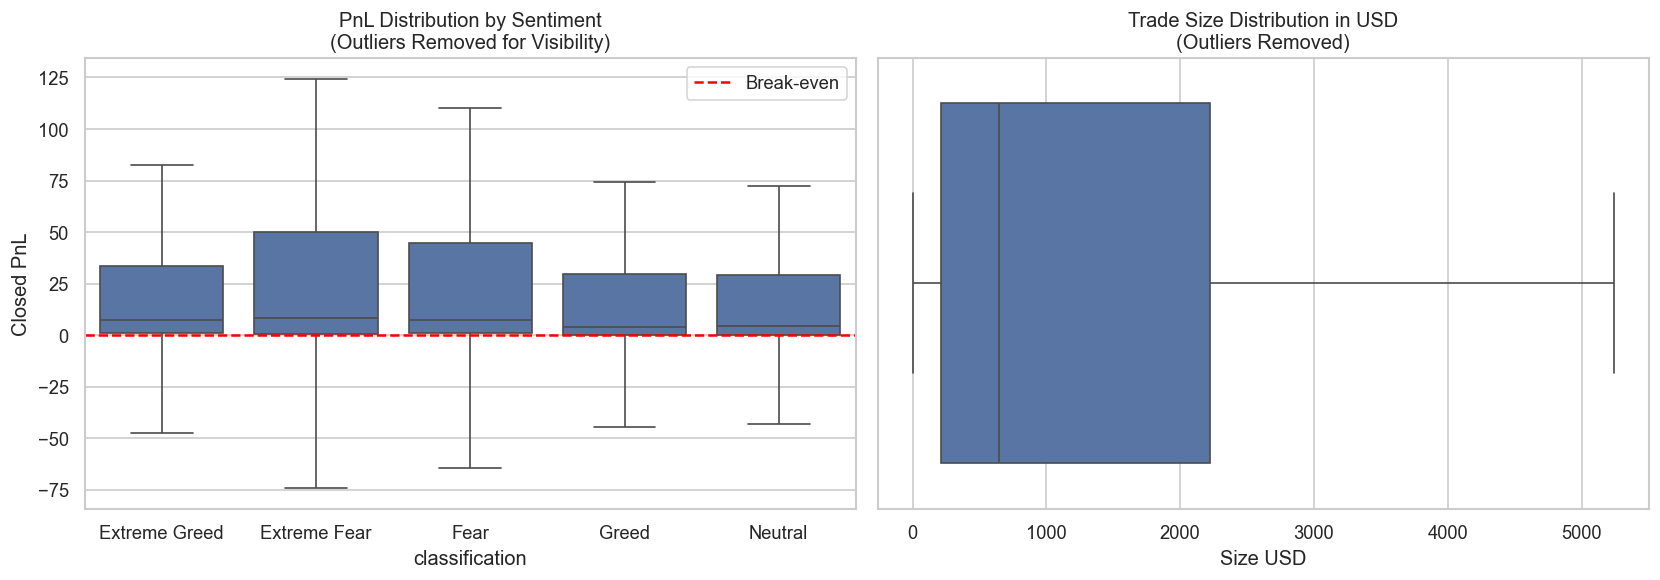

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PnL by sentiment — outliers hidden for readability
sns.boxplot(data=df_closed, x="classification", y="Closed PnL", showfliers=False, ax=axes[0])
axes[0].axhline(y=0, color="red", linestyle="--", label="Break-even")
axes[0].set_title("PnL Distribution by Sentiment\n(Outliers Removed for Visibility)")
axes[0].legend()

# Trade size distribution
sns.boxplot(x=df_closed["Size USD"], showfliers=False, ax=axes[1])
axes[1].set_title("Trade Size Distribution in USD\n(Outliers Removed)")

plt.tight_layout()
plt.show()

### Distribution Notes
- `showfliers=False` hides extreme whale trades (max +$135k, min -$118k) to show the typical distribution clearly.
- Median PnL is above zero across all sentiment categories — this dataset skews toward profitable traders.
- **Fear** shows the widest IQR, suggesting more variable position-taking during fearful markets (aggressive dip-buying or stop-loss exits).

## 5. Performance by Sentiment

In [57]:
pnl_by_sent = (
    df_closed.groupby("classification")
    .agg(
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("is_profitable", "mean"),
        total_trades=("Closed PnL", "count"),
        avg_size_usd=("Size USD", "mean")
    )
    .reset_index()
    .sort_values("avg_pnl", ascending=False)
)
display(pnl_by_sent)

,classification,avg_pnl,win_rate,total_trades,avg_size_usd
2,Fear,126.413972,0.885918,26481,8857.667254
0,Extreme Fear,95.254470,0.799637,9358,5880.463817
3,Greed,69.172563,0.760766,19320,6614.316019
4,Neutral,68.317023,0.830020,15843,6110.902113
1,Extreme Greed,46.227967,0.873858,13683,3488.460061


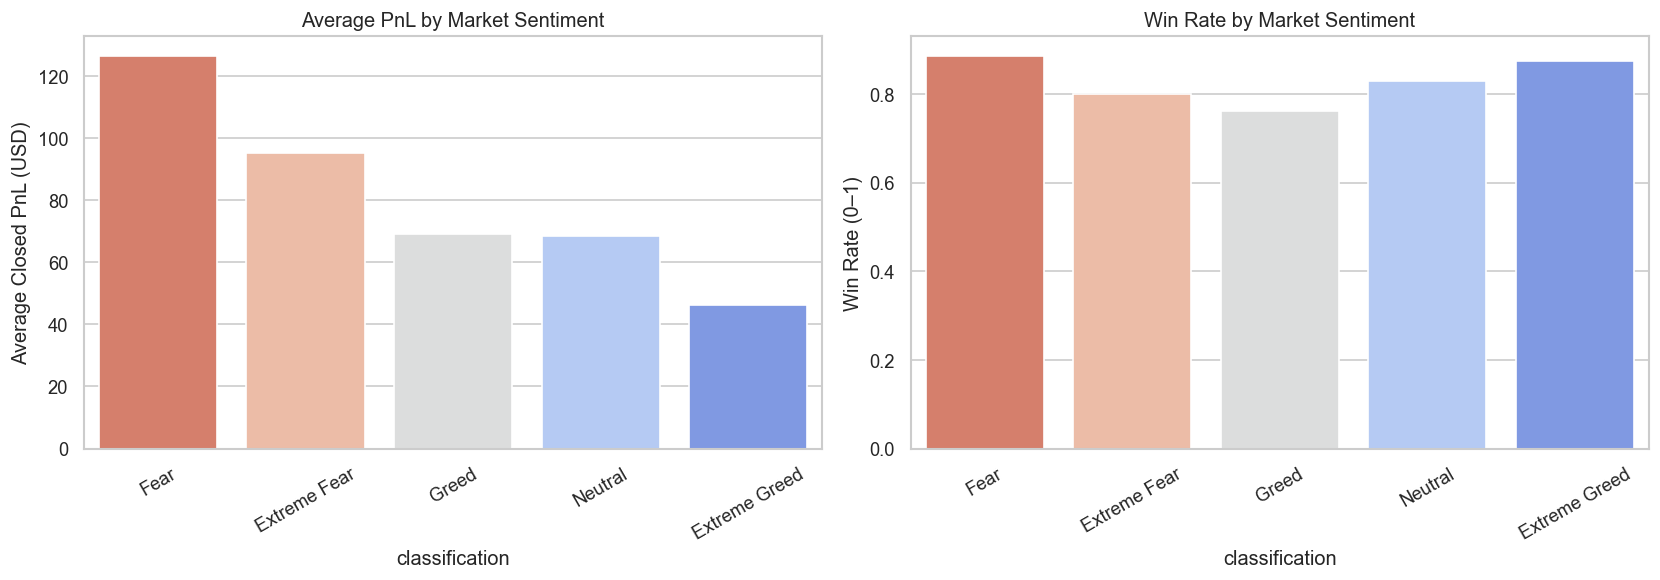

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=pnl_by_sent, x="classification", y="avg_pnl", palette="coolwarm_r", ax=axes[0])
axes[0].set_title("Average PnL by Market Sentiment")
axes[0].set_ylabel("Average Closed PnL (USD)")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=pnl_by_sent, x="classification", y="win_rate", palette="coolwarm_r", ax=axes[1])
axes[1].set_title("Win Rate by Market Sentiment")
axes[1].set_ylabel("Win Rate (0–1)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Key Finding — Fear Outperforms Greed

| Sentiment     | Avg PnL   | Win Rate | Trades |
|---------------|-----------|----------|--------|
| Fear          | **$126.41** | **88.6%** | 26,481 |
| Extreme Fear  | $95.25    | 80.0%    | 9,358  |
| Neutral       | $68.32    | 83.0%    | 15,843 |
| Greed         | $69.17    | 76.1%    | 19,320 |
| Extreme Greed | $46.23    | 87.4%    | 13,683 |

**Counter-intuitive result:** Traders earn the most and win most often during **Fear** sentiment — not Greed.

**Why this makes sense:**
- During fear, traders are selective — only entering with high conviction, leading to better entries.
- Greed phases attract FOMO entries and overtrading, reducing average quality.
- Consistent with the classic principle: *be greedy when others are fearful.*

## 6. Correlation Analysis

Pearson r = -0.2503
P-value   = 0.000000


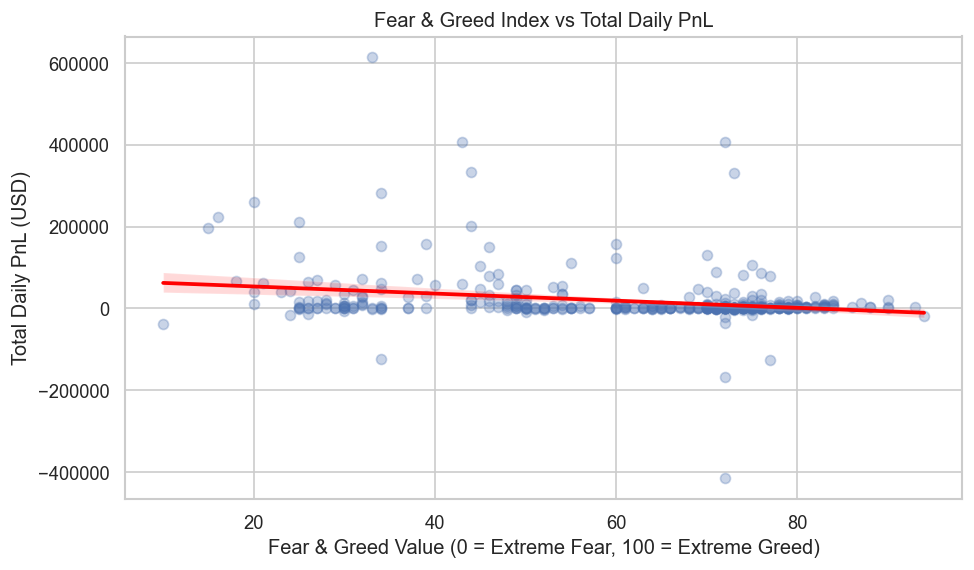

In [59]:
# Daily aggregate PnL
daily_pnl = df_closed.groupby("date").agg(daily_pnl=("Closed PnL", "sum")).reset_index()
daily_pnl["date"] = pd.to_datetime(daily_pnl["date"])

sent_num = sentiment.copy()
sent_num["date"] = pd.to_datetime(sent_num["date"])

daily = daily_pnl.merge(sent_num[["date","value"]], on="date", how="left").dropna()

corr, p = stats.pearsonr(daily["value"], daily["daily_pnl"])
print(f"Pearson r = {corr:.4f}")
print(f"P-value   = {p:.6f}")

plt.figure(figsize=(9, 5))
sns.regplot(data=daily, x="value", y="daily_pnl", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Fear & Greed Index vs Total Daily PnL")
plt.xlabel("Fear & Greed Value (0 = Extreme Fear, 100 = Extreme Greed)")
plt.ylabel("Total Daily PnL (USD)")
plt.show()

### Correlation Interpretation
**Pearson r = −0.25, p < 0.000001**

- **Negative correlation**: as greed rises, aggregate daily PnL slightly falls.
- **Statistically significant** (p < 0.000001) — not random.
- **Weak effect size** (r² ≈ 6.3%) — sentiment explains only ~6% of PnL variance. Volatility, coin selection, and position sizing explain the rest.
- **Trading implication:** High-greed environments are mildly unfavourable for this trader pool — consistent with the Fear outperformance finding.

## 7. Trading Activity Analysis

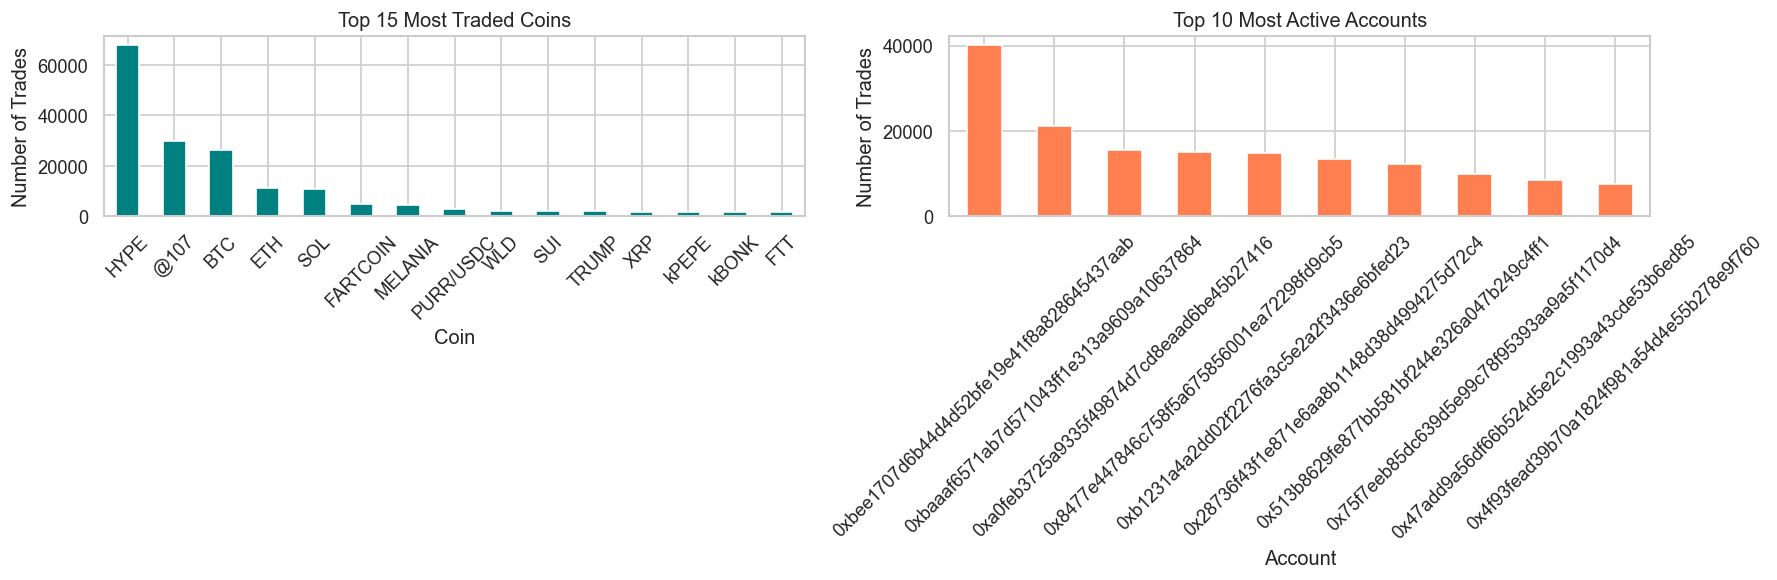

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df["Coin"].value_counts().head(15).plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Top 15 Most Traded Coins")
axes[0].set_ylabel("Number of Trades")
axes[0].tick_params(axis='x', rotation=45)

df["Account"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Top 10 Most Active Accounts")
axes[1].set_ylabel("Number of Trades")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Activity Insights
- **HYPE** (Hyperliquid's native token) dominates with ~32% of all trades — traders actively speculate on the platform's own token.
- **BTC and ETH** follow as expected — standard for any derivatives platform.
- Meme coins (FARTCOIN, MELANIA) appearing in the top 10 reflect the speculative 2024–2025 bull cycle on Hyperliquid.

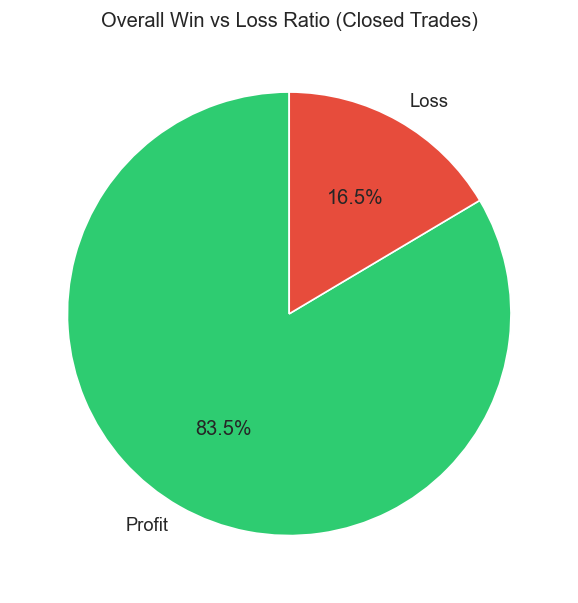

In [61]:
# Win/Loss pie — FIXED label mapping
win_loss = df_closed["is_profitable"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    win_loss,
    labels=win_loss.index.map({True: "Profit", False: "Loss"}),
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90
)
plt.title("Overall Win vs Loss Ratio (Closed Trades)")
plt.show()

### Win Rate Note
- **~83.5% overall win rate** across 84,691 closed trades is exceptionally high.
- This persists across all sentiment conditions (minimum ~76% in Greed) — suggesting the dataset represents skilled or systematic traders.

## 8. Statistical Significance Test

In [63]:
from scipy.stats import kruskal

clean = df_closed.dropna(subset=["classification", "Closed PnL"])

groups = [
    clean[clean["classification"] == cat]["Closed PnL"]
    for cat in clean["classification"].unique()
]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.4f}")
print(f"P-value          = {p:.8f}")

if p < 0.05:
    print("\nResult: Statistically SIGNIFICANT — sentiment groups have different PnL distributions.")
else:
    print("\nResult: Not significant.")

Kruskal-Wallis H = 738.4341
P-value          = 0.00000000

Result: Statistically SIGNIFICANT — sentiment groups have different PnL distributions.


### Statistical Test Interpretation
**Kruskal-Wallis H = 738.43, p < 0.000001**

- **Kruskal-Wallis** chosen over ANOVA because PnL is heavily skewed and non-normal — standard for financial data.
- The null hypothesis (all sentiment groups produce equal PnL) is **strongly rejected**.
- **Conclusion:** Sentiment category is a **statistically meaningful predictor** of trading outcomes — this is not a chance observation.

## 9. Conclusions & Strategy Recommendations

### Key Findings

1. **Fear is the best time to trade** — Highest avg PnL ($126.41) and win rate (88.6%) during Fear sentiment. Most actionable and counter-intuitive finding.

2. **Greed underperforms** — Despite bullish sentiment, Greed periods show the lowest win rate (76.1%), consistent with FOMO-driven overtrading degrading trade quality.

3. **Statistically confirmed** — Kruskal-Wallis (H=738.43, p<0.000001) confirms these differences are real, not random.

4. **Weak negative correlation (r = −0.25)** — Higher greed weakly but significantly correlates with lower daily aggregate PnL.

5. **HYPE dominates activity** — 32% of trades are in Hyperliquid's own token; BTC and ETH follow.

6. **High baseline win rate (83.5%)** — Dataset represents skilled traders; even worst-case (Greed) stays above 76%.

### Strategy Recommendations

> **Use the Fear & Greed Index as a contrarian signal:**
> - Increase position sizing and aggression during **Fear / Extreme Fear**
> - Reduce position sizing, tighten stop-losses during **Greed / Extreme Greed**
> - Focus on **BTC, ETH, and HYPE** as the most liquid markets in this dataset
> - Trade selectivity (fewer, higher-conviction trades) appears to drive the Fear outperformance — mimic this behavior regardless of sentiment